In [1]:
import torch

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


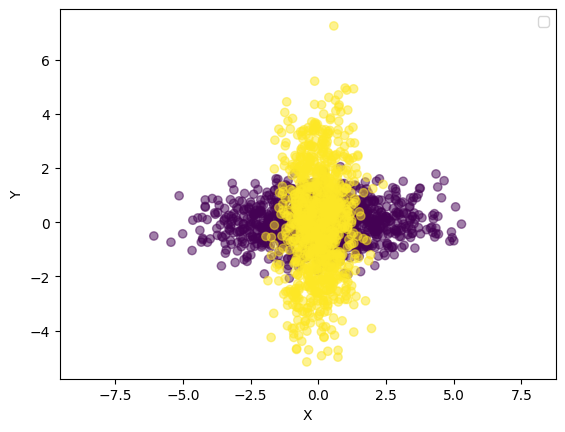

In [2]:
# construct data set as the mixture of 2 Gaussians in the plane
n_samples = 1000
mean = torch.tensor([0.0, 0.0])
cov1 = torch.tensor([[4., 0.0], [0.0, 0.5]])
cov2 = torch.tensor([[0.5, 0.0], [0.0, 4.0]])
dist1 = torch.distributions.MultivariateNormal(mean, cov1)
dist2 = torch.distributions.MultivariateNormal(mean, cov2)

samples1 = dist1.sample((n_samples,))
samples2 = dist2.sample((n_samples,))

data = torch.cat([samples1, samples2], dim=0)
labels = torch.cat([torch.zeros(n_samples), torch.ones(n_samples)], dim=0)

# plot
import matplotlib.pyplot as plt
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='viridis', alpha=0.5)
plt.xlabel("X")
plt.ylabel("Y")
plt.axis('equal')
plt.legend()
plt.show()

In [3]:
from sklearn.decomposition import FastICA
from sklearn.cluster import KMeans

def ica_cluster_covariances_torch(data, n_components, n_clusters):
    """
    data: (N, d) torch tensor
    Returns:
      cluster_covs: list of (d, d) torch tensors, one per cluster in original space
      labels: (N,) cluster assignments
    """

    # 1) FastICA: get sources
    ica = FastICA(n_components=n_components, whiten="unit-variance", random_state=0)
    sources_np = ica.fit_transform(data.numpy())      # (N, k) sources
    print(sources_np)
    A = ica.mixing_                              # (d, k) mixing matrix
    print("A:", A)

    # 2) Classify by finding a k-sparse direction in source space, take absolute values, then k-means
    W = torch.from_numpy(ica.components_) # (k, d) unmixing matrix
    sources_t = torch.from_numpy(sources_np) # (N, k)
    sparse_dir = W[0]  # (d,) take first row of W
    print("sparse_dir:", sparse_dir)
    projections = sources_t @ sparse_dir             # (N,)
    abs_proj = torch.abs(projections)                # (N,)
    abs_proj_np = abs_proj.cpu().numpy().reshape(-1, 1)
    kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(abs_proj_np)
    labels = torch.from_numpy(kmeans.labels_)  # (N,)    

    # 3) For each cluster, compute covariance in original space
    data_t = data.float()  # (N, d)
    cluster_covs = []

    for c in range(n_clusters):
        idx = (labels == c)
        if idx.sum() < 2:
            # degenerate cluster: fallback to tiny isotropic covariance
            d = data_t.shape[1]
            cov_c = 1e-6 * torch.eye(d)
        else:
            Xc = data_t[idx]                                # (Nc, d)
            Xc = Xc - Xc.mean(dim=0, keepdim=True)
            Nc = Xc.shape[0]
            cov_c = (Xc.T @ Xc) / (Nc - 1)                  # (d, d)
        cluster_covs.append(cov_c)

    return cluster_covs, labels



In [4]:
cluster_covs, labels = ica_cluster_covariances_torch(data, n_components=2, n_clusters=2)

print("Cluster covariances:\n", [cov for cov in cluster_covs])  
print("Labels shape:", labels.shape)  # (N,)


[[ 1.5918148  -0.51204807]
 [-0.06641891  0.00238936]
 [-0.59959435  0.17190634]
 ...
 [ 0.6555182  -0.47057974]
 [ 1.0017531  -1.1816409 ]
 [ 0.39645246  0.14286922]]
A: [[-1.4461783   0.02030972]
 [-0.02804263  1.4544657 ]]
sparse_dir: tensor([-0.6917,  0.0097])


/home/wdiepeveen/projects/Lyme-Geometry/.venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Cluster covariances:
 [tensor([[7.8380, 0.2058],
        [0.2058, 0.6027]]), tensor([[0.5697, 0.0343],
        [0.0343, 2.5200]])]
Labels shape: torch.Size([2000])


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


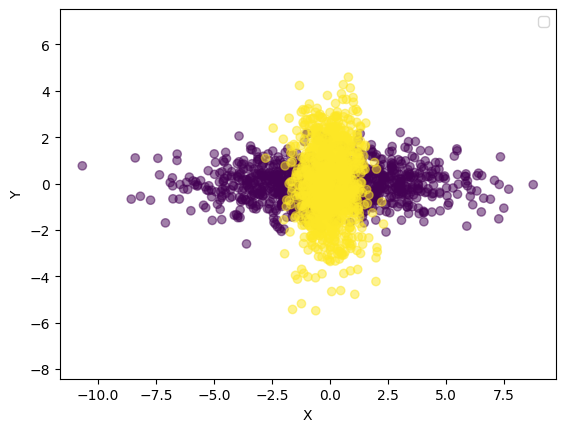

In [5]:
# construct a GMM with 2 components and fit to the data
dist1_learned = torch.distributions.MultivariateNormal(mean, cluster_covs[0].cpu())
dist2_learned = torch.distributions.MultivariateNormal(mean, cluster_covs[1].cpu())

samples1_learned = dist1_learned.sample((n_samples,))
samples2_learned = dist2_learned.sample((n_samples,))

data_learned = torch.cat([samples1_learned, samples2_learned], dim=0)
labels_learned = torch.cat([torch.zeros(n_samples), torch.ones(n_samples)], dim=0)

# plot
import matplotlib.pyplot as plt
plt.scatter(data_learned[:, 0], data_learned[:, 1], c=labels_learned, cmap='viridis', alpha=0.5)
plt.xlabel("X")
plt.ylabel("Y")
plt.axis('equal')
plt.legend()
plt.show()